<a href="https://colab.research.google.com/github/bahawal-khan/DeepLearning-practice/blob/main/CNN/Filter_by_filter_image_improvement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

uploaded = files.upload()

Saving human.jpg to human.jpg


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.models import Model

In [3]:
base_model = ResNet50(weights="imagenet")

102967424/102967424 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [7]:
base_model.summary()

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 25,636,712 (97.80 MB)

 Trainable params: 25,583,592 (97.59 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [4]:
img = image.load_img("human.jpg", target_size=(224,224))

img_array = image.img_to_array(img)

img_batch = np.expand_dims(img_array, axis=0)

img_batch = preprocess_input(img_batch)

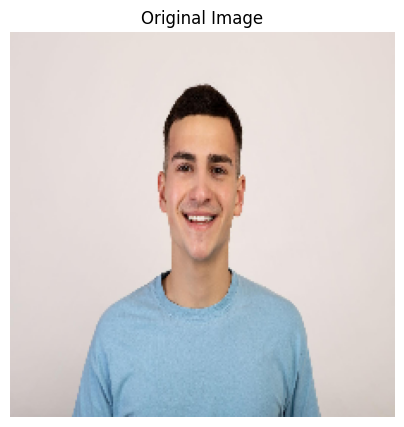

In [5]:
plt.figure(figsize=(5,5))
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")
plt.show()

**LAYER1:**
Captures basic features such as edges, lines, and brightness patterns

In [8]:
print(base_model.layers[1].name)

conv1_pad


In [9]:
feature_model = Model(
    inputs=base_model.input,
    outputs=base_model.get_layer("conv1_conv").output
)

In [10]:
feature_maps = feature_model.predict(img_batch)

print(feature_maps.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
(1, 112, 112, 64)


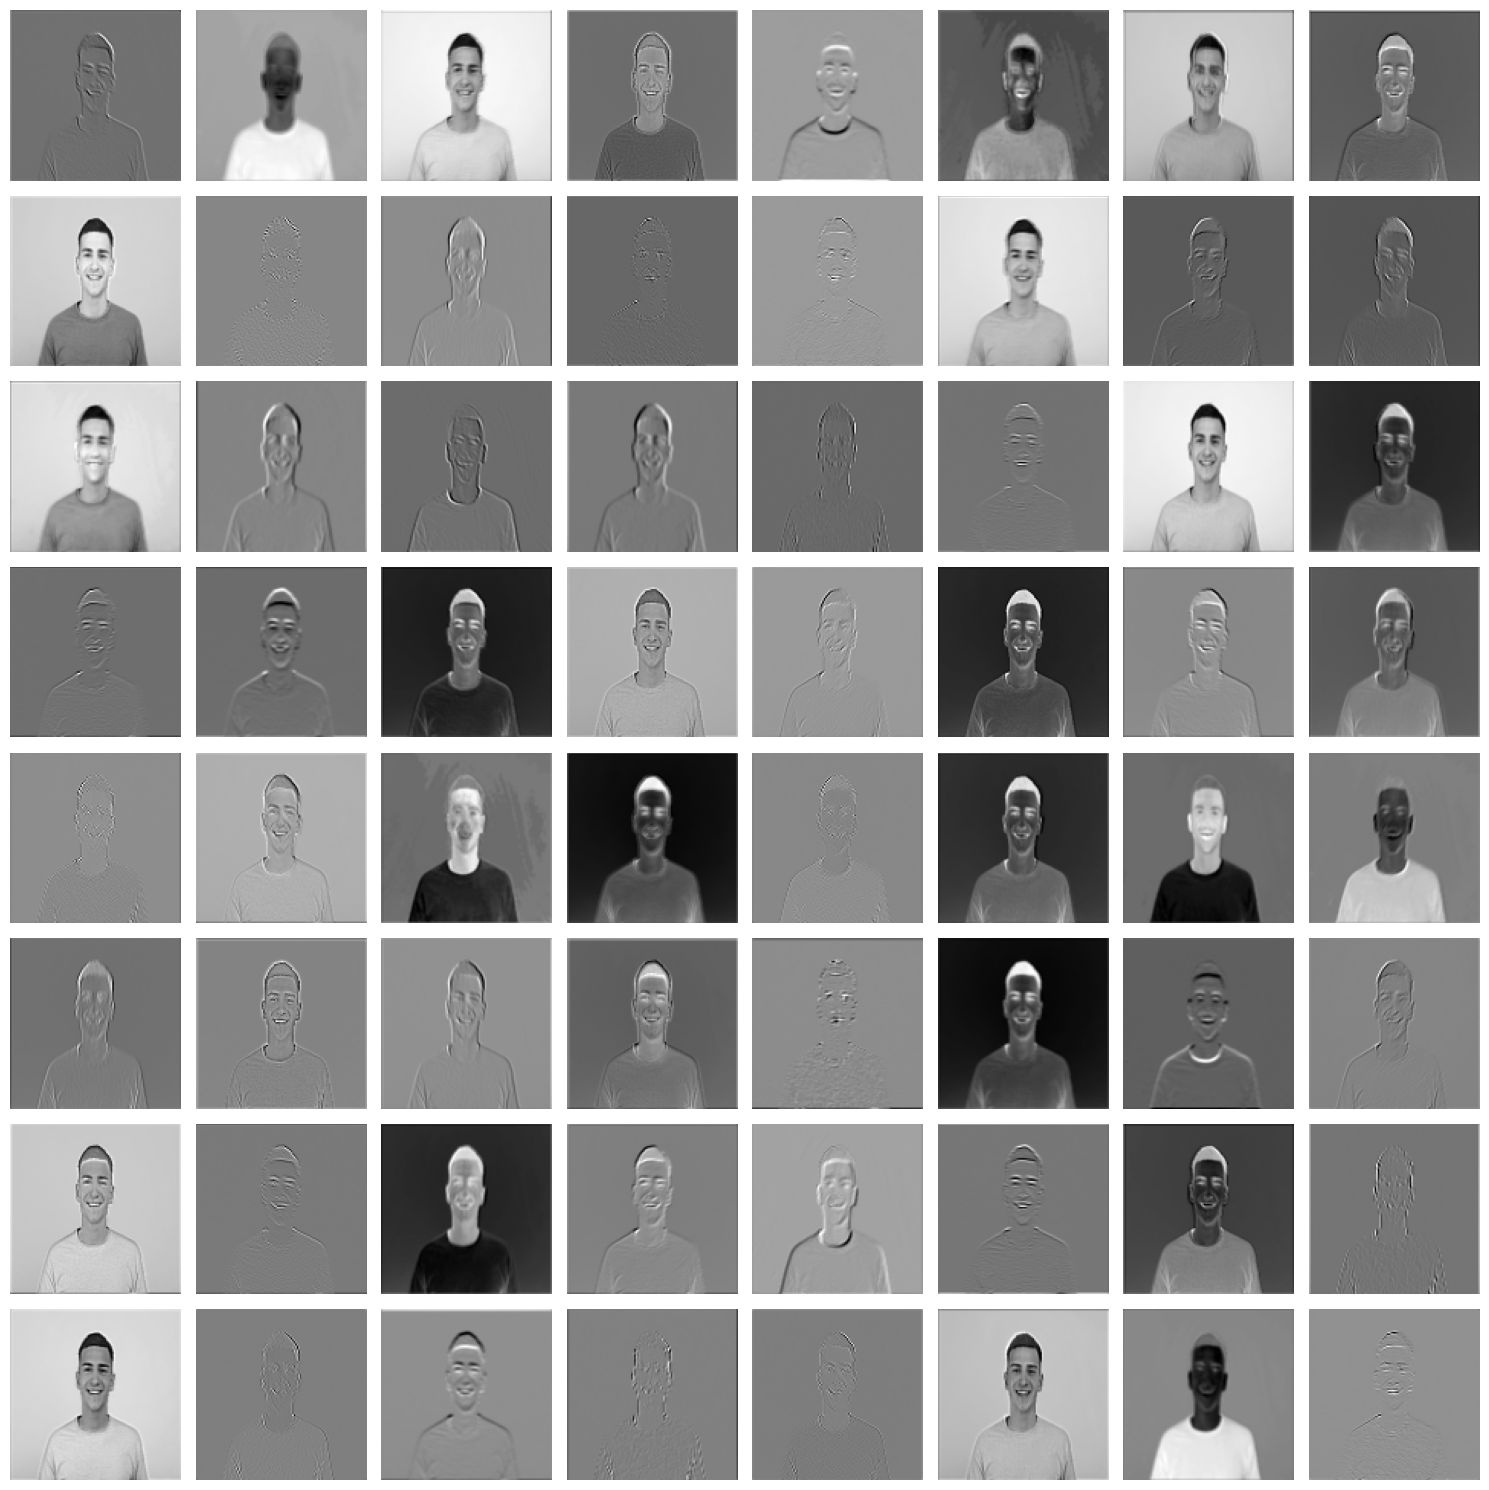

In [11]:
plt.figure(figsize=(15,15))

for i in range(64):

    plt.subplot(8,8,i+1)

    plt.imshow(feature_maps[0,:,:,i], cmap="gray")

    plt.axis("off")

plt.tight_layout()

plt.show()

In [12]:
for i, layer in enumerate(base_model.layers):
    print(i, layer.name)

0 input_layer
1 conv1_pad
2 conv1_conv
3 conv1_bn
4 conv1_relu
5 pool1_pad
6 pool1_pool
7 conv2_block1_1_conv
8 conv2_block1_1_bn
9 conv2_block1_1_relu
10 conv2_block1_2_conv
11 conv2_block1_2_bn
12 conv2_block1_2_relu
13 conv2_block1_0_conv
14 conv2_block1_3_conv
15 conv2_block1_0_bn
16 conv2_block1_3_bn
17 conv2_block1_add
18 conv2_block1_out
19 conv2_block2_1_conv
20 conv2_block2_1_bn
21 conv2_block2_1_relu
22 conv2_block2_2_conv
23 conv2_block2_2_bn
24 conv2_block2_2_relu
25 conv2_block2_3_conv
26 conv2_block2_3_bn
27 conv2_block2_add
28 conv2_block2_out
29 conv2_block3_1_conv
30 conv2_block3_1_bn
31 conv2_block3_1_relu
32 conv2_block3_2_conv
33 conv2_block3_2_bn
34 conv2_block3_2_relu
35 conv2_block3_3_conv
36 conv2_block3_3_bn
37 conv2_block3_add
38 conv2_block3_out
39 conv3_block1_1_conv
40 conv3_block1_1_bn
41 conv3_block1_1_relu
42 conv3_block1_2_conv
43 conv3_block1_2_bn
44 conv3_block1_2_relu
45 conv3_block1_0_conv
46 conv3_block1_3_conv
47 conv3_block1_0_bn
48 conv3_block1_

**LAYER3:**
Captures textures and object parts, such as eyes, hair, nose, and facial outlines.

In [13]:
layer_name = "conv3_block4_out"

feature_model = Model(
    inputs=base_model.input,
    outputs=base_model.get_layer(layer_name).output
)

feature_maps = feature_model.predict(img_batch)

print(feature_maps.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 906ms/step
(1, 28, 28, 512)


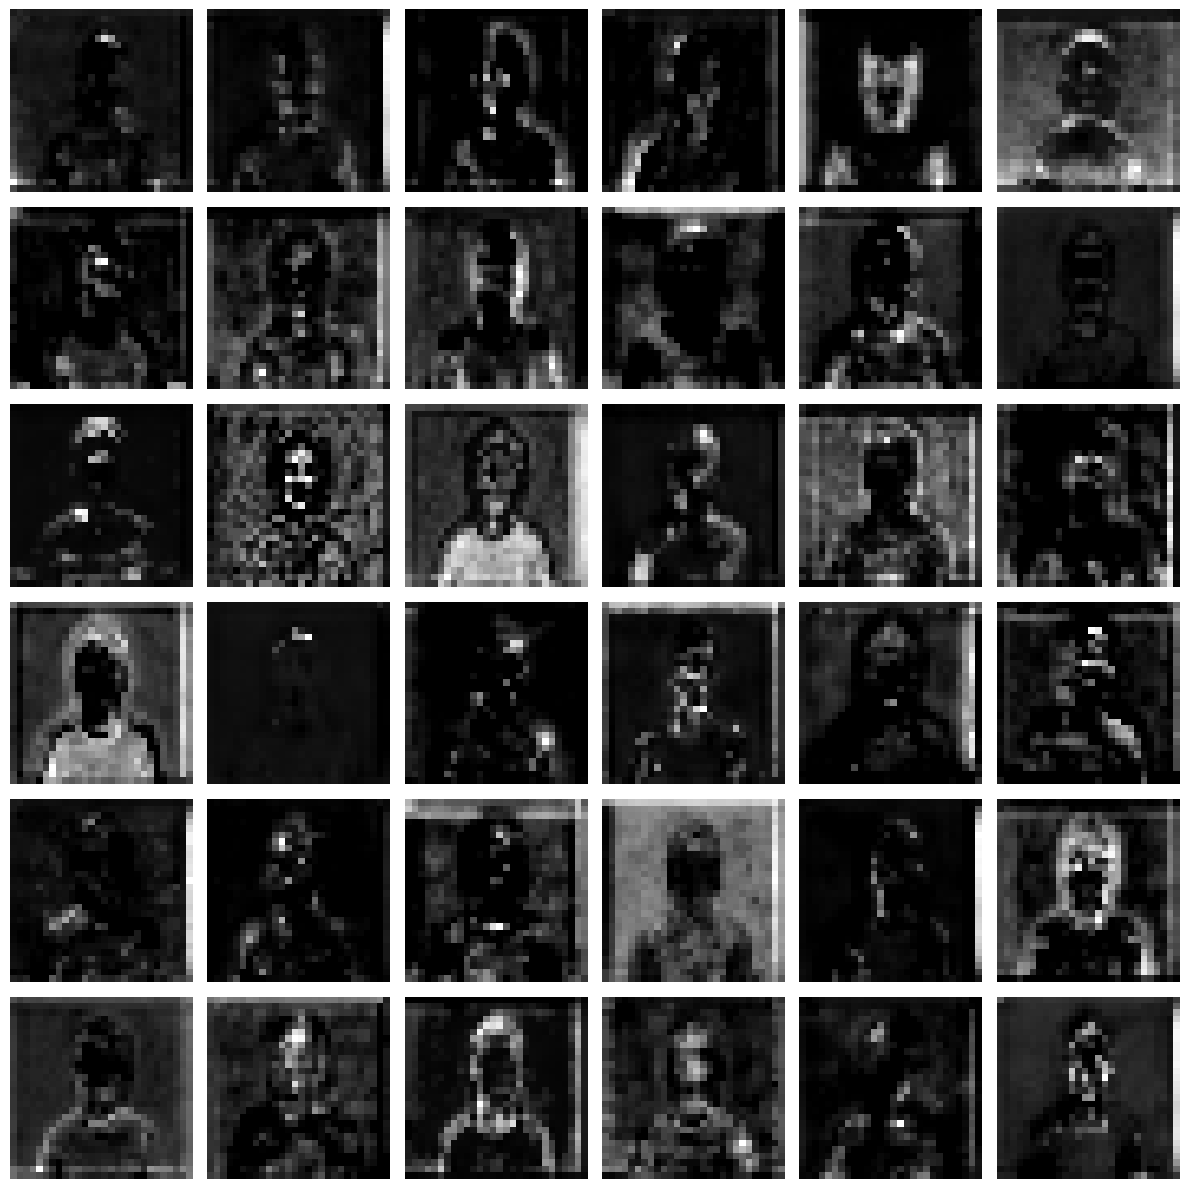

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,12))

for i in range(36):

    plt.subplot(6,6,i+1)

    plt.imshow(feature_maps[0,:,:,i], cmap="gray")

    plt.axis("off")

plt.tight_layout()

plt.show()

**Layer 2 (Conv2):**
Captures simple textures, corners, and local patterns by combining basic edge features.

In [18]:
layer_name = "conv2_block3_out"

In [19]:
feature_model = Model(
    inputs=base_model.input,
    outputs=base_model.get_layer(layer_name).output
)

feature_maps = feature_model.predict(img_batch)

print(feature_maps.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 707ms/step
(1, 56, 56, 256)


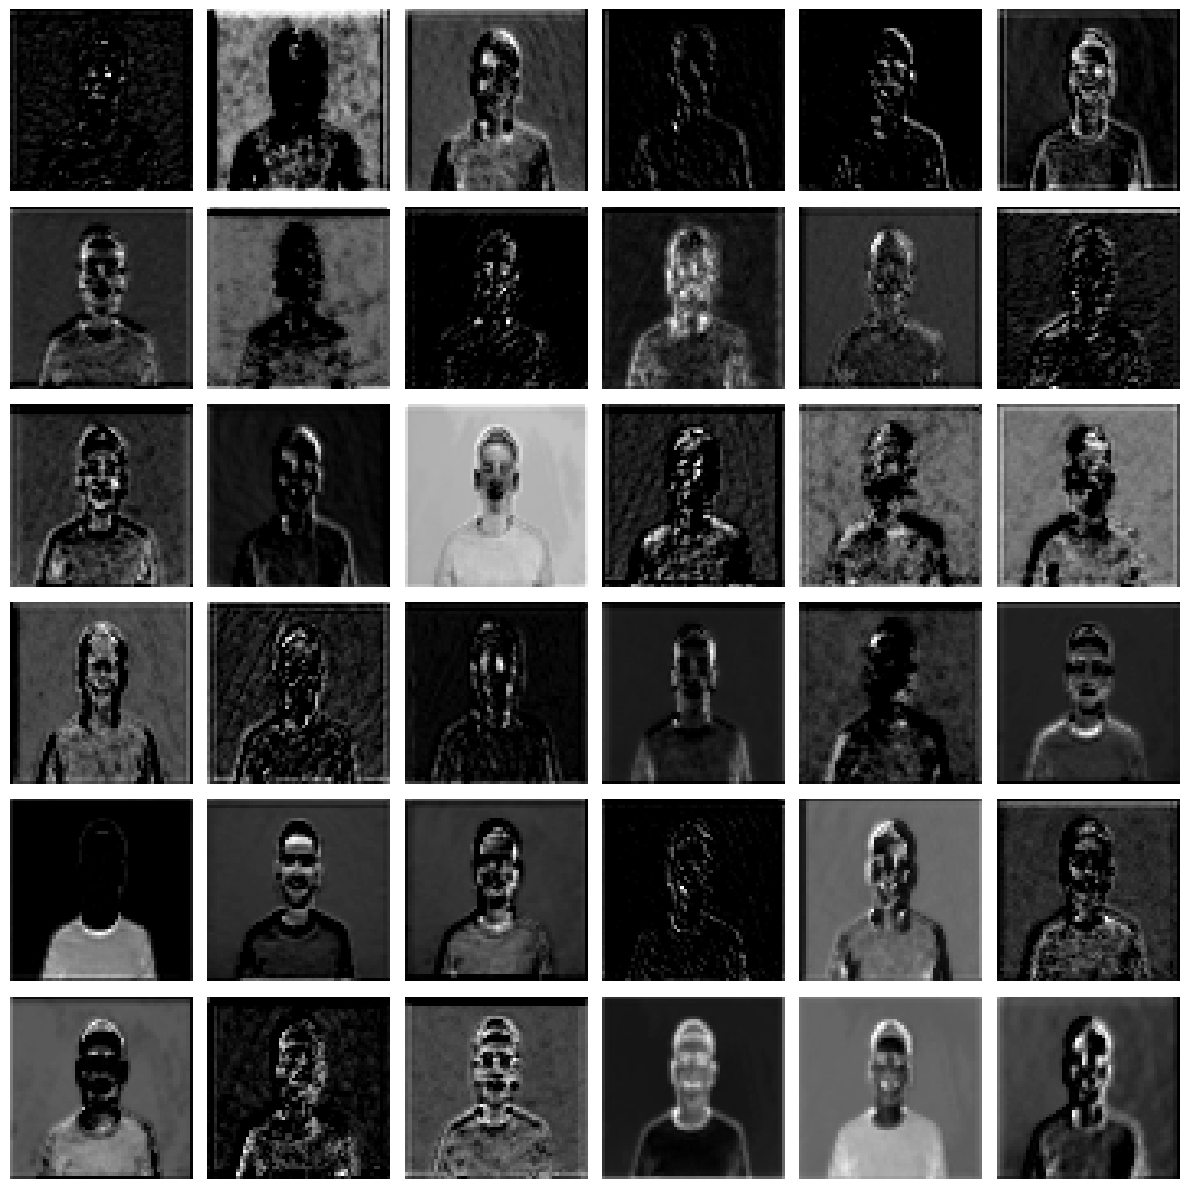

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,12))

for i in range(36):
    plt.subplot(6,6,i+1)
    plt.imshow(feature_maps[0,:,:,i], cmap="gray")
    plt.axis("off")

plt.tight_layout()
plt.show()

**Layer 3 (Conv3)**
Captures textures and object parts, such as eyes, hair, nose, and facial outlines.

In [21]:
layer_name = "conv3_block4_out"

In [22]:
feature_model = Model(
    inputs=base_model.input,
    outputs=base_model.get_layer(layer_name).output
)

feature_maps = feature_model.predict(img_batch)

print(feature_maps.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 933ms/step
(1, 28, 28, 512)


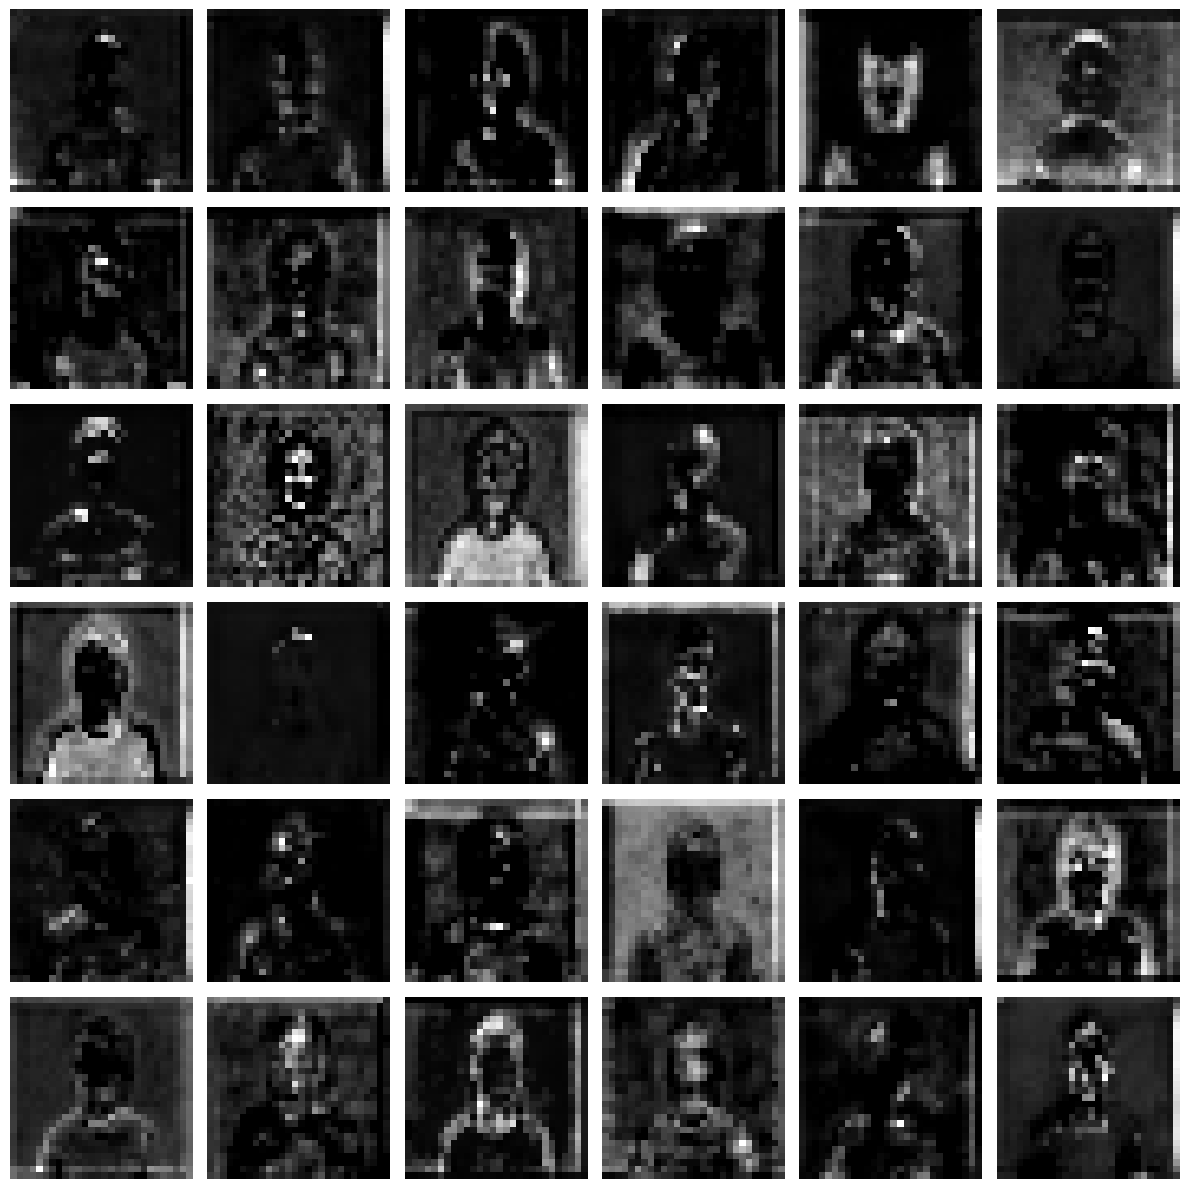

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,12))

for i in range(36):
    plt.subplot(6,6,i+1)
    plt.imshow(feature_maps[0,:,:,i], cmap="gray")
    plt.axis("off")

plt.tight_layout()
plt.show()

**Layer 4 (Conv4)**
Captures high-level object structures, including face shape, body parts, and overall object patterns.

In [24]:
layer_name = "conv4_block6_out"

In [25]:
feature_model = Model(
    inputs=base_model.input,
    outputs=base_model.get_layer(layer_name).output
)

feature_maps = feature_model.predict(img_batch)

print(feature_maps.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
(1, 14, 14, 1024)


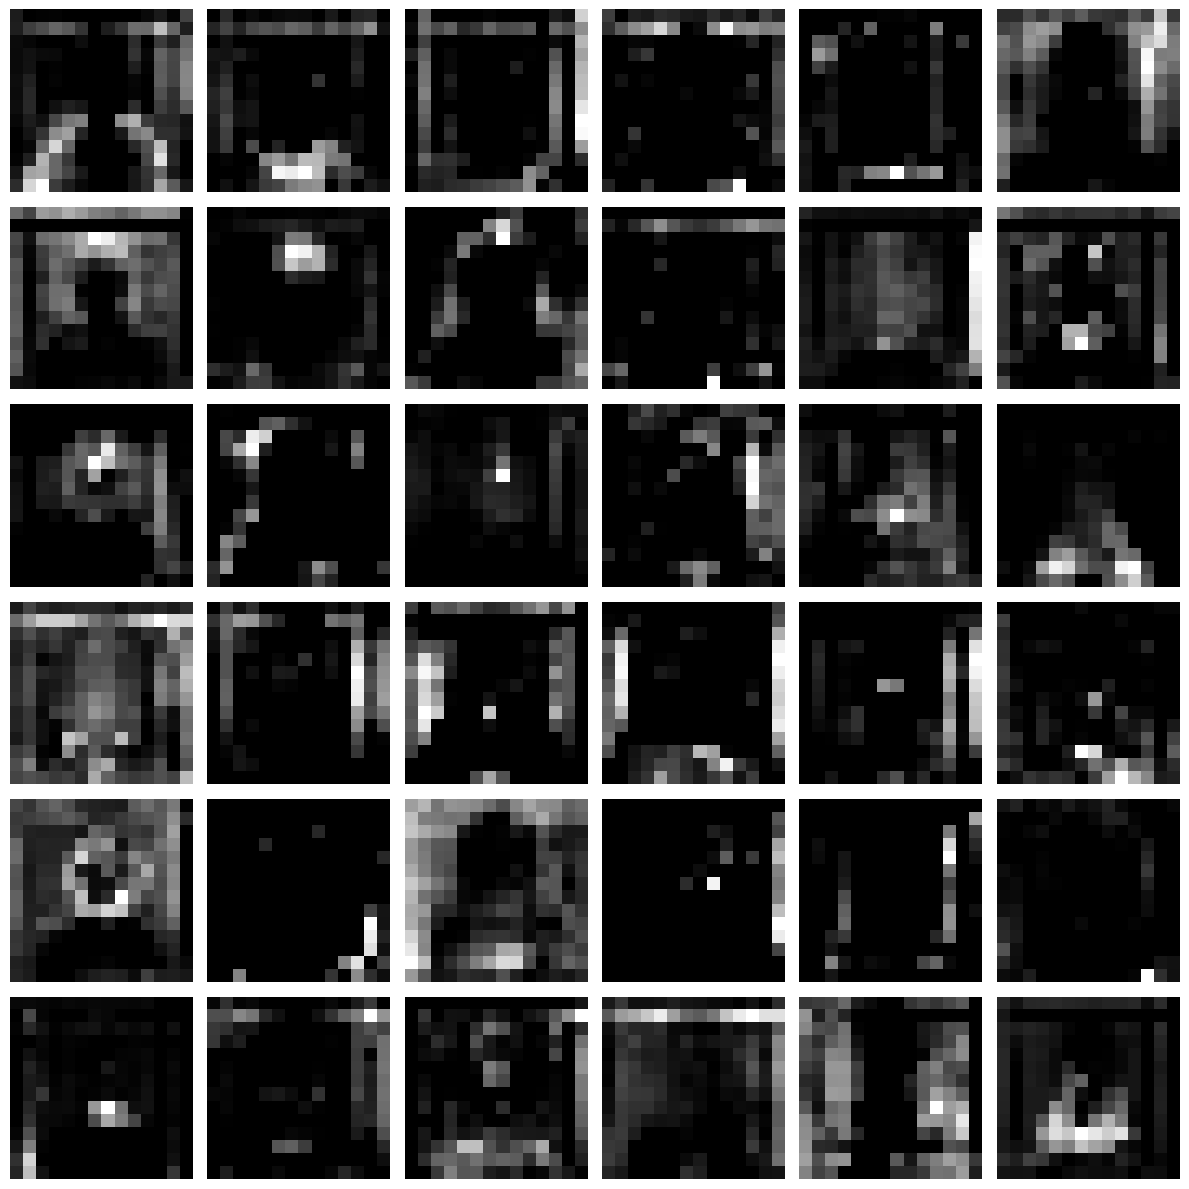

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,12))

for i in range(36):
    plt.subplot(6,6,i+1)
    plt.imshow(feature_maps[0,:,:,i], cmap="gray")
    plt.axis("off")

plt.tight_layout()
plt.show()